# Proyek Akhir: Klasifikasi Tingkat Obesitas Berdasarkan Gaya Hidup
Proyek ini berfokus pada prediksi dan analisis tingkat obesitas seseorang berdasarkan pola makan dan kondisi fisiknya.

## 1. Import Library

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset
Membaca dataset dari file CSV yang telah disediakan.

In [22]:
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 3. Exploratory Data Analysis (EDA)
Menganalisis informasi dasar dari dataset dan memvisualisasikan beberapa korelasi penting.

In [23]:
# Cek informasi baris, kolom, dan tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

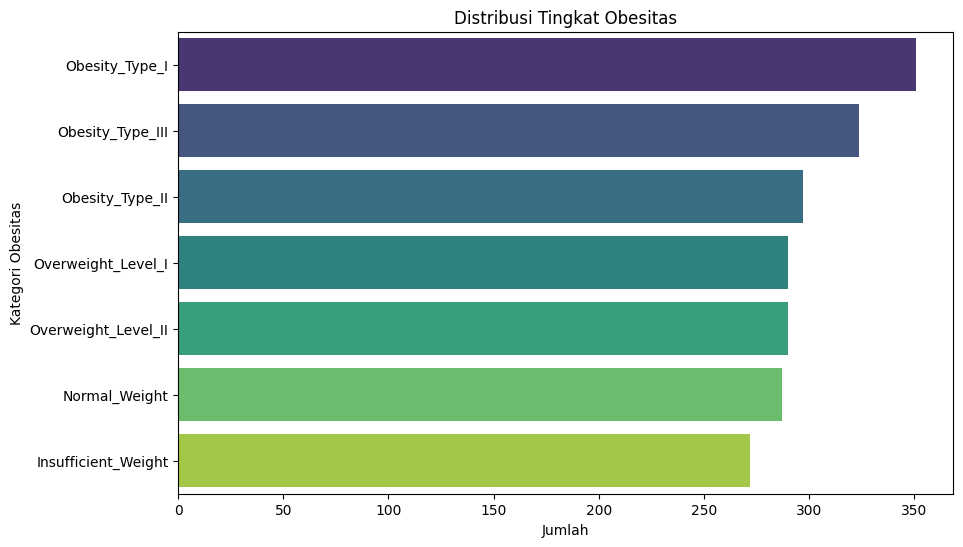

In [24]:
# Visualisasi Distribusi Tingkat Obesitas
plt.figure(figsize=(10,6))
sns.countplot(y='NObeyesdad', data=df, order=df['NObeyesdad'].value_counts().index, palette='viridis')
plt.title('Distribusi Tingkat Obesitas')
plt.xlabel('Jumlah')
plt.ylabel('Kategori Obesitas')
plt.show()

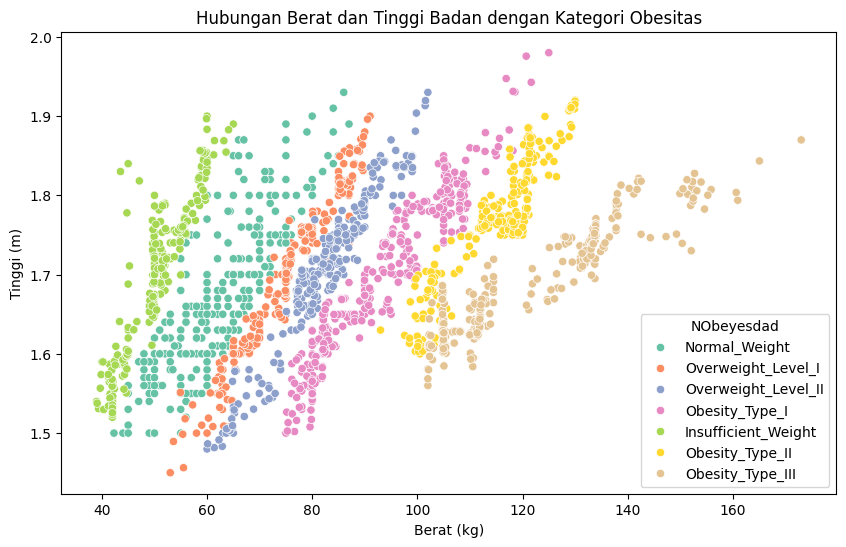

In [25]:
# Visualisasi Hubungan Tinggi vs Berat Badan
plt.figure(figsize=(10,6))
sns.scatterplot(x='Weight', y='Height', hue='NObeyesdad', data=df, palette='Set2')
plt.title('Hubungan Berat dan Tinggi Badan dengan Kategori Obesitas')
plt.xlabel('Berat (kg)')
plt.ylabel('Tinggi (m)')
plt.show()

## 4. Data Preparation
Memisahkan fitur (X) dan target (y), serta mengubah tinggi badan dari meter menjadi sentimeter.

In [26]:
# Konversi Tinggi dari meter ke cm (agar konsisten dengan input pengguna di aplikasi web)
df['Height'] = df['Height'] * 100

# Memisahkan atribut fitur dan target label
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

# Encoding label target menjadi bentuk numerik
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Menyimpan peta label
target_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Mapping Kelas Target:\n", target_mapping)

Mapping Kelas Target:
 {'Insufficient_Weight': np.int64(0), 'Normal_Weight': np.int64(1), 'Obesity_Type_I': np.int64(2), 'Obesity_Type_II': np.int64(3), 'Obesity_Type_III': np.int64(4), 'Overweight_Level_I': np.int64(5), 'Overweight_Level_II': np.int64(6)}


## 5. Preprocessing & Modeling Pipeline
Membuat *Pipeline* untuk otomatisasi preprocessing (StandardScaler & OneHotEncoder) sekaligus melatih model Random Forest Classifier.

In [27]:
# Identifikasi kolom numerik dan kategorikal
numeric_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
categorical_features = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

# Membuat transformer untuk kolom
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# Membuat pipeline dengan model Random Forest
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Membagi data menjadi 80% Training dan 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

## 6. Training & Evaluation
Melatih model menggunakan data training dan mengevaluasi seberapa akurat model memprediksi pada data testing.

In [28]:
# Proses Training Model
model_pipeline.fit(X_train, y_train)

# Prediksi
y_pred = model_pipeline.predict(X_test)

# Evaluasi Akurasi
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {akurasi * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Akurasi Model: 94.09%

Classification Report:
                      precision    recall  f1-score   support

Insufficient_Weight       1.00      0.94      0.97        54
      Normal_Weight       0.76      0.93      0.84        58
     Obesity_Type_I       0.96      0.96      0.96        70
    Obesity_Type_II       1.00      0.98      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.94      0.86      0.90        58
Overweight_Level_II       0.96      0.91      0.94        58

           accuracy                           0.94       423
          macro avg       0.95      0.94      0.94       423
       weighted avg       0.95      0.94      0.94       423



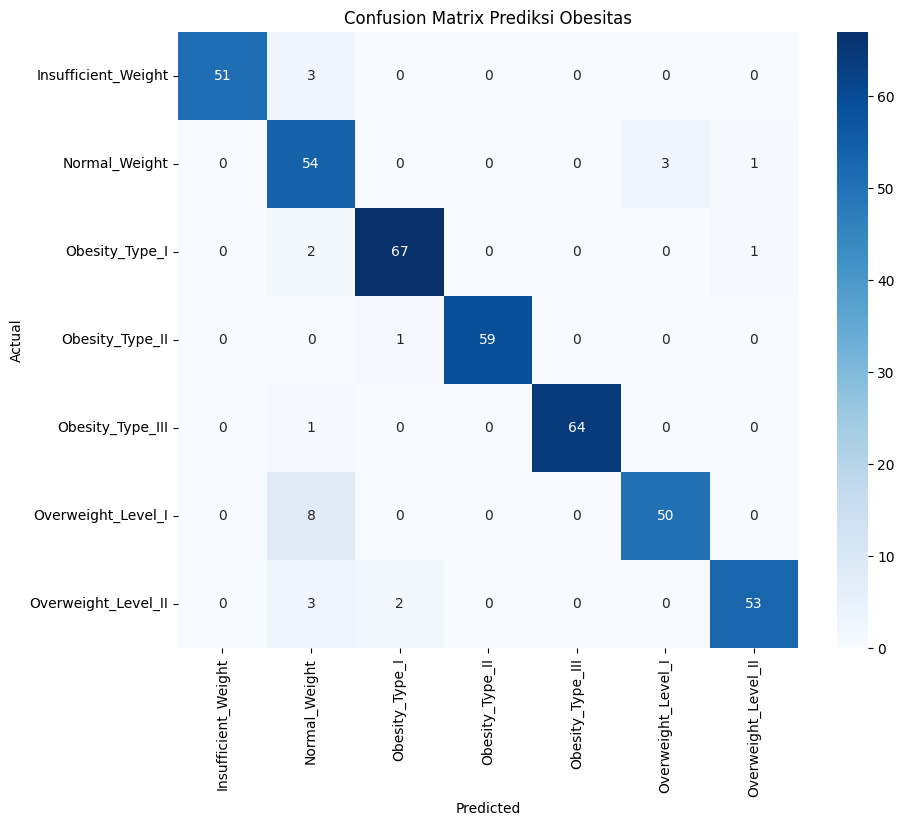

In [29]:
# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix Prediksi Obesitas')
plt.show()

## 7. Extract Feature Importance
Melihat fitur gaya hidup mana yang paling dominan dalam memengaruhi obesitas.

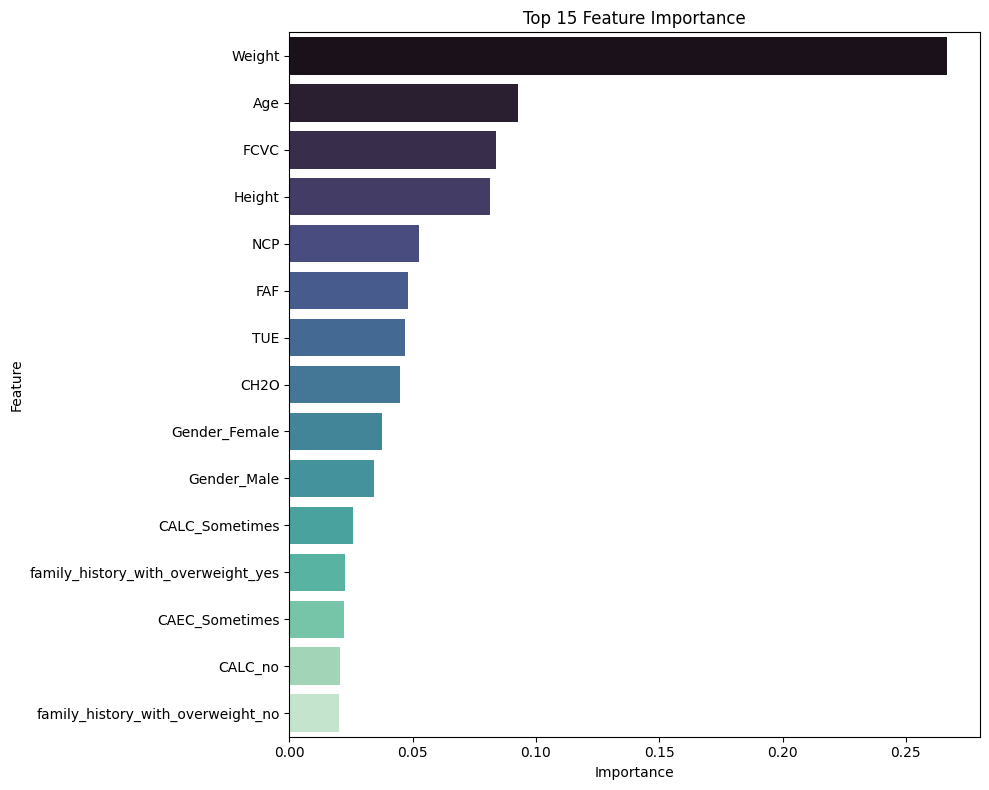

In [30]:
# Mendapatkan nama fitur dari preprocessor setelah one-hot encoding
cat_features_encoded = model_pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_features)
all_features = numeric_features + list(cat_features_encoded)

# Mengambil Feature Importance dari Random Forest
importances = model_pipeline.named_steps['classifier'].feature_importances_
feature_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(15), palette='mako')
plt.title('Top 15 Feature Importance')
plt.tight_layout()
plt.show()

## 8. Export Model
Langkah terakhir adalah menyimpan *pipeline model* dan *label encoder* ke file `.pkl` untuk dihubungkan ke aplikasi web.

In [31]:
joblib.dump(model_pipeline, 'model.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')
print("Model Random Forest berhasil disimpan ke file 'model.pkl'!")

Model Random Forest berhasil disimpan ke file 'model.pkl'!
